# Effect Sizes

## Overview

Effect sizes quantify the magnitude of a difference or relationship, independent of sample size. P-values indicate detectability; effect sizes indicate importance.

| Context | Effect size | Benchmarks (Cohen) |
|---|---|---|
| Two means | Cohen's d | 0.2 / 0.5 / 0.8 |
| Paired means | Cohen's dz | same |
| ANOVA | omega-squared | 0.01 / 0.06 / 0.14 |
| Correlation | r | 0.1 / 0.3 / 0.5 |
| Chi-square | Cramer's V | 0.1 / 0.3 / 0.5 |
| Non-parametric | Rank-biserial r | 0.1 / 0.3 / 0.5 |

Cohen's benchmarks are domain-agnostic defaults. Use domain knowledge wherever possible.

---

In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.api as sm
rng = np.random.default_rng(42)
ctrl = rng.normal(18, 5, 100)
rest = rng.normal(20, 5, 100)

---
## Cohen's d and Hedges' g

In [6]:
pooled_sd = np.sqrt((ctrl.std(ddof=1)**2 + rest.std(ddof=1)**2)/2)
d = (rest.mean()-ctrl.mean()) / pooled_sd
correction = 1 - 3/(4*(len(ctrl)+len(rest)-2)-1)
g = d * correction
print(f"Cohen's d = {d:.3f}")
print(f"Hedges'  g = {g:.3f}  (bias-corrected; prefer for n<30 per group)")
print(f"Means: ctrl={ctrl.mean():.2f}, rest={rest.mean():.2f}, pooled SD={pooled_sd:.2f}")

Cohen's d = 0.497
Hedges'  g = 0.495  (bias-corrected; prefer for n<30 per group)
Means: ctrl=17.75, rest=19.95, pooled SD=4.42


---
## Effect Size Visualisation: Distribution Overlap

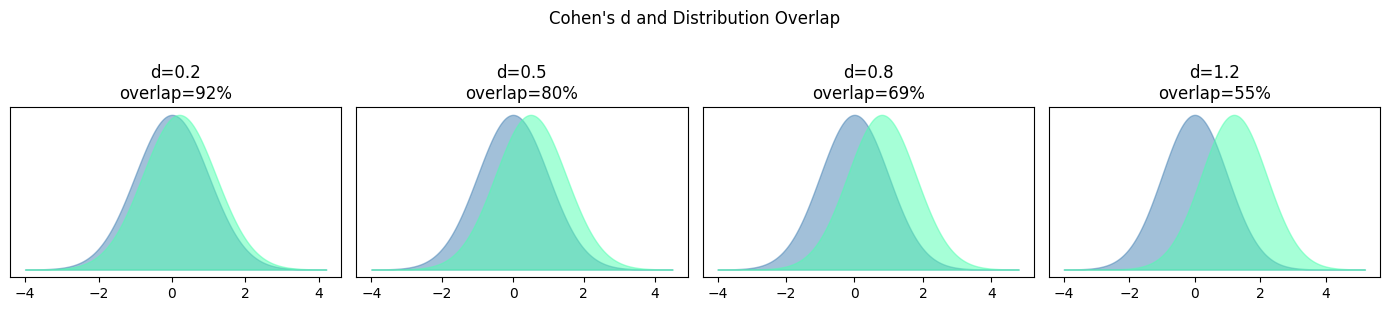

In [7]:
ds = [0.2, 0.5, 0.8, 1.2]
fig, axes = plt.subplots(1,4,figsize=(14,3))
for ax, dv in zip(axes, ds):
    x = np.linspace(-4, 4+dv, 400)
    ax.fill_between(x, stats.norm.pdf(x,0,1),  alpha=0.5, color="steelblue", label="Control")
    ax.fill_between(x, stats.norm.pdf(x,dv,1), alpha=0.5, color="#4fffb0",   label="Restored")
    overlap = 2*stats.norm.cdf(-dv/2)
    ax.set_title(f"d={dv}\noverlap={overlap:.0%}")
    ax.set_yticks([])
plt.suptitle("Cohen's d and Distribution Overlap", y=1.02)
plt.tight_layout(); plt.show()

---
## omega-squared for ANOVA

In [8]:
catchments=["North","South","East","West"]
df=pd.DataFrame({"catchment":np.repeat(catchments,40),
                 "richness":np.concatenate([rng.normal(m,5,40) for m in [18,21,19,17]])})
model=ols("richness ~ C(catchment)",data=df).fit()
aov=sm.stats.anova_lm(model,typ=2)
ss_b=aov.loc["C(catchment)","sum_sq"]; ss_w=aov.loc["Residual","sum_sq"]
df_b=aov.loc["C(catchment)","df"]
df_w=aov.loc["Residual","df"]
ms_w = ss_w / df_w
omega2=(ss_b-df_b*ms_w)/(ss_b+ss_w+ms_w)
eta2=ss_b/(ss_b+ss_w)
print(f"eta-squared   = {eta2:.3f}  (upward bias)")
print(f"omega-squared = {omega2:.3f}  (bias-corrected -- prefer)")

eta-squared   = 0.099  (upward bias)
omega-squared = 0.081  (bias-corrected -- prefer)


---
## Bootstrap CIs for Effect Sizes

Cohen's d = 0.497, Bootstrap 95% CI: [0.224, 0.767]


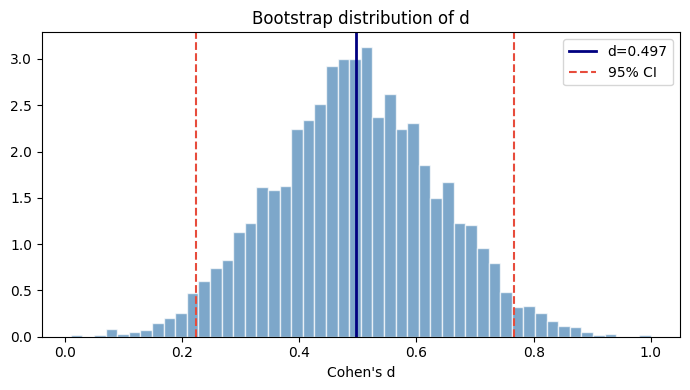

In [9]:
B=3000
boot_d=[]
for _ in range(B):
    c=rng.choice(ctrl,len(ctrl),replace=True)
    r=rng.choice(rest,len(rest),replace=True)
    ps=np.sqrt((c.std(ddof=1)**2+r.std(ddof=1)**2)/2)
    boot_d.append((r.mean()-c.mean())/ps)
ci_d=np.percentile(boot_d,[2.5,97.5])
print(f"Cohen's d = {d:.3f}, Bootstrap 95% CI: [{ci_d[0]:.3f}, {ci_d[1]:.3f}]")
plt.figure(figsize=(7,4))
plt.hist(boot_d,bins=50,color="steelblue",alpha=0.7,edgecolor="white",density=True)
plt.axvline(d,color="navy",lw=2,label=f"d={d:.3f}")
plt.axvline(ci_d[0],color="#e74c3c",lw=1.5,linestyle="--",label="95% CI")
plt.axvline(ci_d[1],color="#e74c3c",lw=1.5,linestyle="--")
plt.legend(); plt.xlabel("Cohen's d"); plt.title("Bootstrap distribution of d")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Not reporting effect sizes at all**  
P-values depend on sample size; effect sizes do not. With n=1000 you can detect d=0.05 as significant. Always report the effect size so readers can judge practical importance.

**2. Using Cohen's benchmarks as absolute standards**  
These were derived from social psychology. A d=0.2 effect on species richness may be highly meaningful in ecology. Ground interpretation in domain knowledge.

**3. Reporting eta-squared without noting its upward bias**  
eta-squared overestimates the population effect, especially for small samples. Report omega-squared alongside or instead.

**4. Using Cohen's d for non-normal or skewed data**  
Cohen's d relies on the SD as a measure of spread. For non-normal data the SD is unreliable. Use rank-biserial r for Mann-Whitney results, or report the median difference with a bootstrap CI.

**5. Not reporting CIs for effect sizes**  
Effect size point estimates are uncertain. A d=0.5 with CI [0.1, 0.9] is very different from d=0.5 with CI [0.4, 0.6]. Report bootstrap CIs for all effect sizes.
---
*python_methods_library - Samantha McGarrigle*